In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/cicids2017_100k.csv")

df = df.dropna()
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

constant_cols = [
    col for col in df.columns
    if df[col].nunique() == 1
]

df = df.drop(columns=constant_cols)

print(df.shape)

(95588, 71)


In [4]:
selected_features = [
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Packet Length Mean',
    'Packet Length Std',
    'Average Packet Size',
    'Flow IAT Mean',
    'Flow IAT Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'Label'
]

df_eda = df[selected_features]

df_eda.head()

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Backward Packets,Packet Length Mean,Packet Length Std,Average Packet Size,Flow IAT Mean,Flow IAT Std,SYN Flag Count,ACK Flag Count,Label
0,162.0,1.061728e+06,24691.358020,2.0,2.0,41.400000,8.763561,51.75,54.0,8.833459e+01,0.0,0.0,BENIGN
1,3.0,1.333333e+06,666666.666700,2.0,0.0,2.000000,0.000000,3.00,3.0,0.000000e+00,0.0,0.0,BENIGN
2,37703637.0,8.036360e+00,0.106091,2.0,2.0,71.400000,28.049955,89.25,12567879.0,2.152181e+07,0.0,0.0,BENIGN
3,30530.0,3.406485e+03,65.509335,1.0,1.0,49.333333,9.237604,74.00,30530.0,0.000000e+00,0.0,0.0,BENIGN
4,44.0,1.363636e+05,45454.545450,1.0,1.0,2.000000,3.464102,3.00,44.0,0.000000e+00,0.0,0.0,PortScan


In [5]:
# Loại bỏ lớp Infiltration 
mask = df_eda['Label'] != "Infiltration"

df_eda = df[mask]

## Các biểu đồ histogram - Dữ liệu phân bố như thế nào?

### Histogram nhóm thời gian

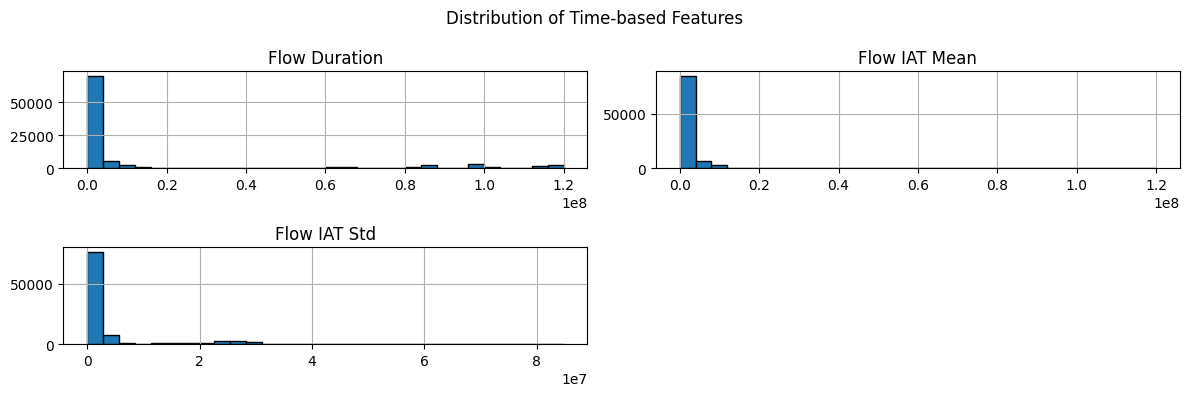

In [6]:
time_features = [
    'Flow Duration',
    'Flow IAT Mean',
    'Flow IAT Std'
]

df_eda[time_features].hist(
    bins=30,
    figsize=(12, 4),
    edgecolor='black'
)

plt.suptitle("Distribution of Time-based Features")
plt.tight_layout()

plt.savefig('../outputs/figures/Histograms_nhom_thoi_gian.png')
plt.show()

Biểu đồ thể hiện phân phối của ba đặc trưng thời gian gồm **Flow Duration**, **Flow IAT Mean** và **Flow IAT Std**.

- Phần lớn các luồng mạng trong tập dữ liệu có thời gian tồn tại ngắn và khoảng cách giữa các gói tin nhỏ. Điều này cho thấy đa số kết nối được thiết lập, trao đổi dữ liệu và kết thúc trong thời gian ngắn.

- Một số ít luồng có thời gian tồn tại dài hơn đáng kể so với phần còn lại của dữ liệu. Những luồng này có thể đại diện cho các phiên truyền dữ liệu kéo dài hoặc các kết nối duy trì liên tục trong mạng.

- Đặc trưng **Flow IAT Mean** cho thấy khoảng thời gian trung bình giữa các gói tin của phần lớn luồng mạng ở mức thấp, phản ánh quá trình trao đổi dữ liệu diễn ra tương đối liên tục.

- Đối với **Flow IAT Std**, đa số các luồng có độ biến thiên thời gian giữa các gói tin không lớn. Tuy nhiên, vẫn tồn tại một số luồng có mức biến động cao hơn, cho thấy tốc độ truyền dữ liệu giữa các gói tin không ổn định trong suốt quá trình giao tiếp.

- Sự khác biệt về thời gian tồn tại của kết nối cũng như khoảng cách giữa các gói tin cho thấy tập dữ liệu bao gồm nhiều kiểu hành vi giao tiếp mạng khác nhau.

Nhóm đặc trưng thời gian phản ánh cách thức các kết nối được duy trì và trao đổi dữ liệu trong mạng. Sự khác biệt giữa các luồng mạng cho thấy đây là nhóm đặc trưng quan trọng, có khả năng hỗ trợ nhận diện và phân biệt giữa lưu lượng bình thường với các hành vi bất thường trong hệ thống mạng.

### Histogram nhóm lưu lượng

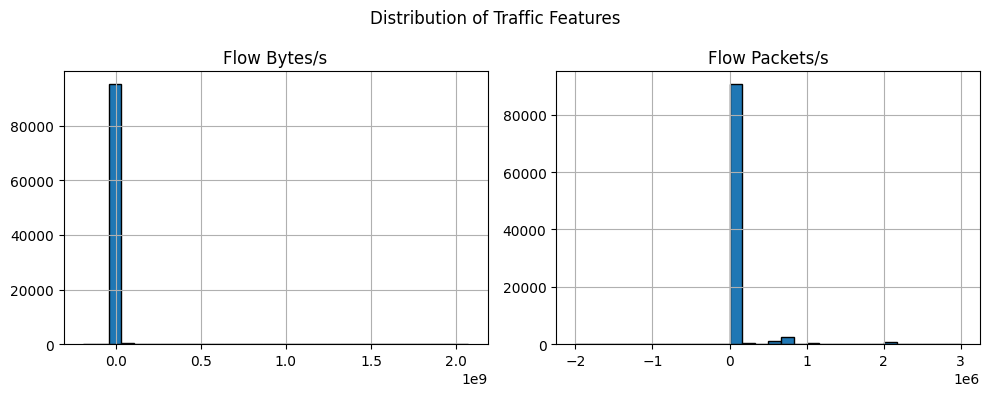

In [7]:
traffic_features = [
    'Flow Bytes/s',
    'Flow Packets/s'
]

df_eda[traffic_features].hist(
    bins=30,
    figsize=(10, 4),
    edgecolor='black'
)

plt.suptitle("Distribution of Traffic Features")
plt.tight_layout()

plt.savefig('../outputs/figures/Histograms_luu_luong.png')
plt.show()

Biểu đồ thể hiện phân phối của hai đặc trưng lưu lượng gồm **Flow Bytes/s** và **Flow Packets/s**.

- Phần lớn các luồng mạng trong tập dữ liệu có tốc độ truyền dữ liệu và tốc độ truyền gói tin ở mức thấp, cho thấy đa số kết nối chỉ trao đổi một lượng thông tin nhỏ trong khoảng thời gian ngắn.

- Tuy nhiên, vẫn tồn tại một số ít luồng có tốc độ truyền dữ liệu và số lượng gói tin trên giây cao hơn rất nhiều so với phần còn lại của dữ liệu. Những luồng này tạo thành các cụm giá trị tách biệt trên biểu đồ.

- Sự khác biệt lớn giữa các luồng mạng cho thấy cường độ lưu lượng trong tập dữ liệu không đồng nhất, phản ánh sự tồn tại của nhiều kiểu giao tiếp mạng khác nhau, từ các kết nối thông thường đến các luồng có lưu lượng lớn.

- Các đặc trưng **Flow Bytes/s** và **Flow Packets/s** phản ánh trực tiếp tốc độ trao đổi dữ liệu của một kết nối, do đó có khả năng cung cấp thông tin quan trọng để phân biệt giữa lưu lượng bình thường và các hành vi sinh lưu lượng bất thường.

Nhóm đặc trưng lưu lượng cho thấy mức độ hoạt động của các luồng mạng có sự khác biệt đáng kể. Các luồng có tốc độ truyền dữ liệu hoặc tốc độ gửi gói tin cao bất thường có thể là dấu hiệu của các hoạt động mạng đặc biệt hoặc các cuộc tấn công tạo ra lưu lượng lớn. Vì vậy, đây là nhóm đặc trưng có giá trị trong bài toán phát hiện xâm nhập mạng.

### Histogram nhóm gói tin

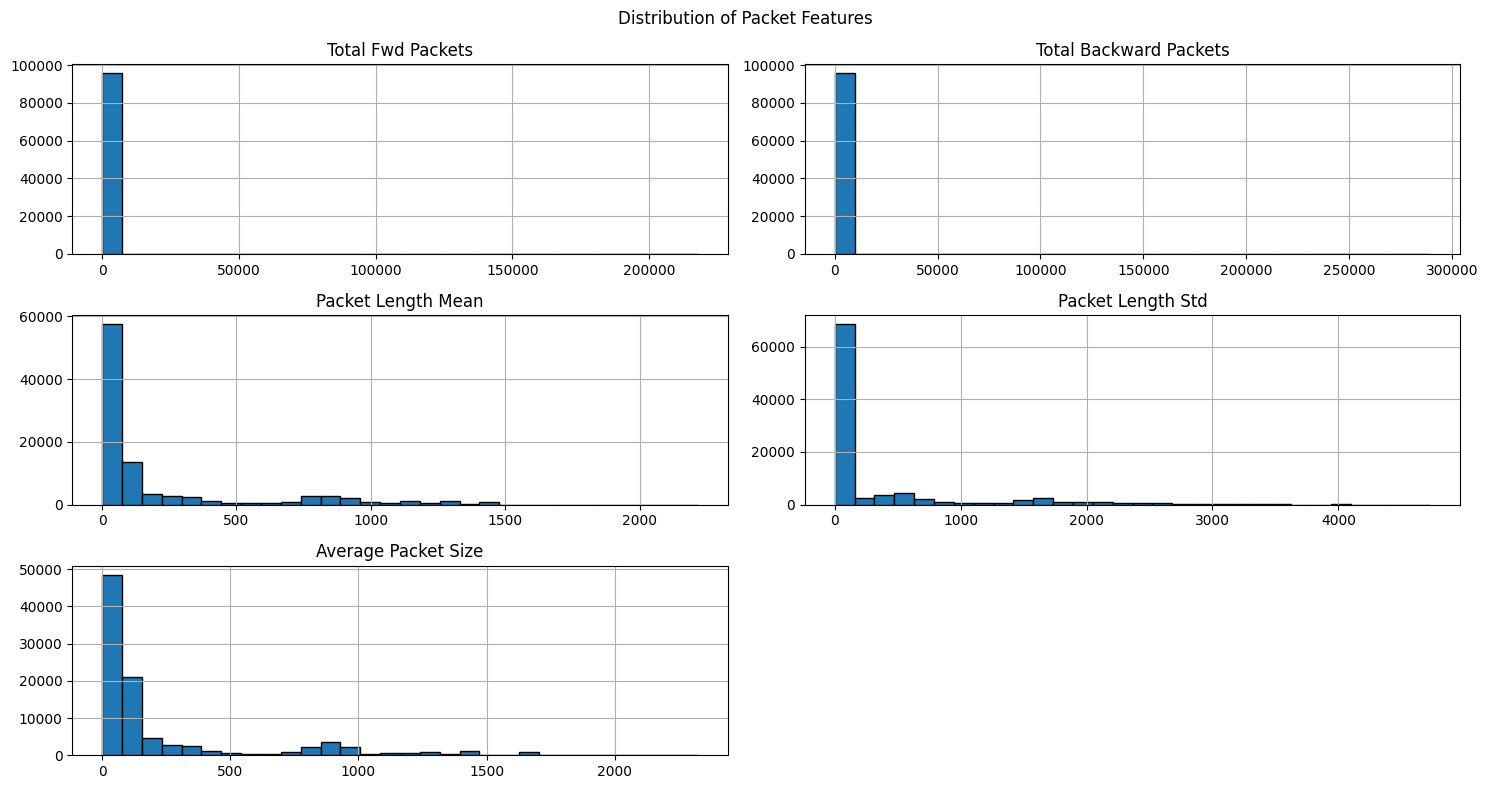

In [8]:
packet_features = [
    'Total Fwd Packets',
    'Total Backward Packets',
    'Packet Length Mean',
    'Packet Length Std',
    'Average Packet Size'
]

df_eda[packet_features].hist(
    bins=30,
    figsize=(15, 8),
    edgecolor='black'
)

plt.suptitle("Distribution of Packet Features")
plt.tight_layout()

plt.savefig('../outputs/figures/Histograms_nhom_goi_tin.png')
plt.show()

Biểu đồ thể hiện phân phối của nhóm đặc trưng liên quan đến số lượng và kích thước gói tin gồm **Total Fwd Packets**, **Total Backward Packets**, **Packet Length Mean**, **Packet Length Std** và **Average Packet Size**.

- Phần lớn các luồng mạng trong tập dữ liệu chỉ chứa số lượng nhỏ gói tin gửi và nhận. Điều này cho thấy đa số kết nối diễn ra trong thời gian ngắn và trao đổi lượng dữ liệu không lớn.

- Tuy nhiên, vẫn tồn tại một số luồng có số lượng gói tin cao hơn đáng kể so với phần còn lại. Những luồng này phản ánh các phiên truyền dữ liệu quy mô lớn hoặc các hoạt động mạng có tần suất trao đổi dữ liệu cao.

- Các đặc trưng **Packet Length Mean**, **Packet Length Std** và **Average Packet Size** cho thấy kích thước gói tin có sự khác biệt rõ rệt giữa các luồng mạng. Trong khi phần lớn luồng có kích thước gói tin tương đối nhỏ và ổn định, một số luồng lại xuất hiện các gói tin lớn hơn hoặc có mức độ biến động kích thước cao hơn.

- Sự khác biệt về số lượng gói tin cũng như kích thước gói tin cho thấy các luồng mạng trong tập dữ liệu có đặc điểm truyền dữ liệu rất đa dạng, phản ánh nhiều kiểu hoạt động mạng khác nhau.

Nhóm đặc trưng về số lượng và kích thước gói tin cung cấp thông tin quan trọng về quy mô và đặc điểm của từng luồng mạng. Sự khác biệt rõ rệt giữa các luồng cho thấy đây là nhóm đặc trưng có khả năng hỗ trợ hiệu quả cho việc phân biệt giữa lưu lượng bình thường và các loại tấn công trong bài toán phát hiện xâm nhập mạng.

### Histogram nhóm TCP Flags

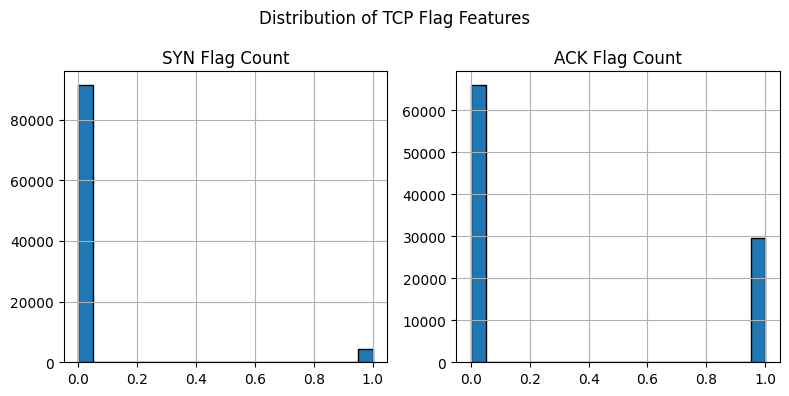

In [9]:
flag_features = [
    'SYN Flag Count',
    'ACK Flag Count'
]

df_eda[flag_features].hist(
    bins=20,
    figsize=(8, 4),
    edgecolor='black'
)

plt.suptitle("Distribution of TCP Flag Features")
plt.tight_layout()
plt.savefig('../outputs/figures/Histograms_nhom_TCP_Flags.png')
plt.show()

Biểu đồ thể hiện phân phối của hai đặc trưng TCP Flag gồm **SYN Flag Count** và **ACK Flag Count**.

- Cả hai đặc trưng chỉ tập trung chủ yếu ở hai giá trị 0 và 1, cho thấy đây là các đặc trưng mang tính chất rời rạc và phản ánh sự xuất hiện của các cờ TCP trong một luồng mạng.

- Đối với **SYN Flag Count**, phần lớn các luồng có giá trị bằng 0 và chỉ một tỷ lệ nhỏ có giá trị bằng 1. Điều này cho thấy không phải mọi luồng mạng đều chứa gói tin khởi tạo kết nối TCP.

- Với **ACK Flag Count**, số lượng luồng có giá trị bằng 1 xuất hiện nhiều hơn đáng kể so với SYN Flag Count. Điều này phản ánh rằng phần lớn các kết nối trong tập dữ liệu đã trải qua quá trình xác nhận và trao đổi dữ liệu sau khi được thiết lập.

- Sự khác biệt về tần suất xuất hiện giữa hai loại cờ TCP cho thấy các luồng mạng trong tập dữ liệu có trạng thái kết nối khác nhau, từ các kết nối mới khởi tạo đến các kết nối đang hoạt động hoặc đã hoàn thành quá trình bắt tay TCP.

Nhóm đặc trưng TCP Flag cung cấp thông tin về trạng thái và quá trình thiết lập kết nối trong mạng. Mặc dù chỉ nhận một số ít giá trị, các đặc trưng này vẫn có ý nghĩa quan trọng trong việc mô tả hành vi giao tiếp TCP và có thể hỗ trợ mô hình nhận diện các hoạt động bất thường như quét cổng, SYN Flood hoặc các cuộc tấn công khai thác giao thức TCP.


### Boxplot Outlier - Dữ liệu phân tán như thế nào và có xuất hiện ngoại lệ hay không?


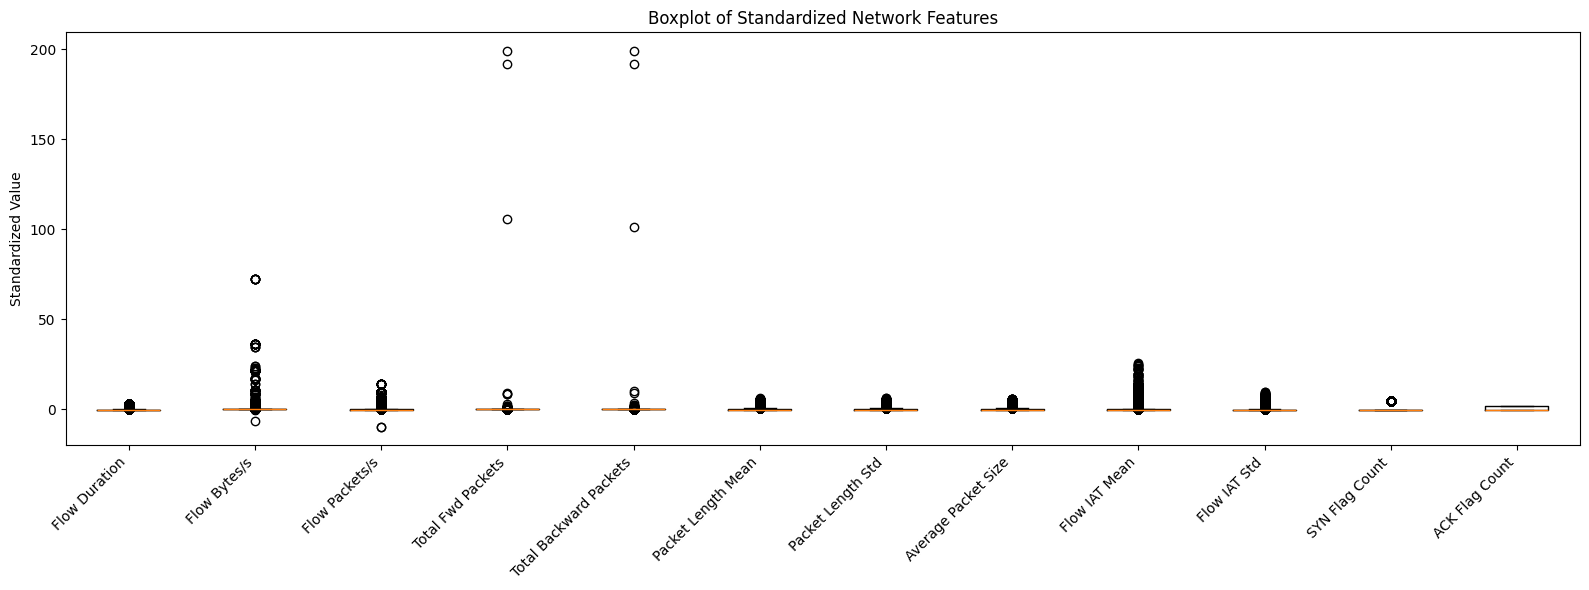

In [10]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

X_scaled = pd.concat([X_train, X_test], axis=0)

plt.figure(figsize=(16, 6))

plt.boxplot(
    [X_scaled[col] for col in X_scaled.columns],
    tick_labels=X_scaled.columns,
    showfliers=True
)

plt.xticks(rotation=45, ha='right')
plt.title("Boxplot of Standardized Network Features")
plt.ylabel("Standardized Value")

plt.tight_layout()

plt.savefig('../outputs/figures/Boxplots_Outlier.png')
plt.show()

Biểu đồ Boxplot cho thấy sự phân bố của 12 đặc trưng mạng sau khi được chuẩn hóa bằng phương pháp StandardScaler.

- Phần lớn các đặc trưng có trung vị (median) nằm gần giá trị 0, cho thấy quá trình chuẩn hóa đã đưa dữ liệu về cùng một thang đo và loại bỏ ảnh hưởng của sự khác biệt về đơn vị đo giữa các đặc trưng.

- Nhiều đặc trưng vẫn xuất hiện số lượng lớn giá trị ngoại lệ (outliers), đặc biệt là **Flow Bytes/s**, **Flow Packets/s**, **Total Fwd Packets**, **Total Backward Packets** và **Flow IAT Mean**. Điều này cho thấy trong tập dữ liệu tồn tại một số luồng mạng có đặc điểm khác biệt đáng kể so với phần lớn các luồng còn lại.

- Hai đặc trưng **Total Fwd Packets** và **Total Backward Packets** có các điểm ngoại lệ xuất hiện rất xa khỏi vùng dữ liệu trung tâm. Điều này phản ánh sự tồn tại của một số luồng có số lượng gói tin gửi hoặc nhận lớn bất thường.

- Các đặc trưng liên quan đến thời gian như **Flow IAT Mean** và **Flow IAT Std** cũng có mức độ phân tán tương đối lớn, cho thấy sự khác biệt rõ rệt về hành vi trao đổi dữ liệu giữa các luồng mạng.

- Trong khi đó, các đặc trưng **SYN Flag Count** và **ACK Flag Count** có phạm vi phân bố hẹp hơn do bản chất là các đặc trưng liên quan đến trạng thái xuất hiện của cờ TCP.

Mặc dù dữ liệu đã được chuẩn hóa, nhiều đặc trưng vẫn tồn tại các giá trị ngoại lệ đáng kể. Điều này phản ánh sự đa dạng trong hành vi của các luồng mạng và cho thấy các đặc trưng được lựa chọn có khả năng chứa thông tin hữu ích để phân biệt giữa lưu lượng bình thường và lưu lượng tấn công.

### Correlation Matrix

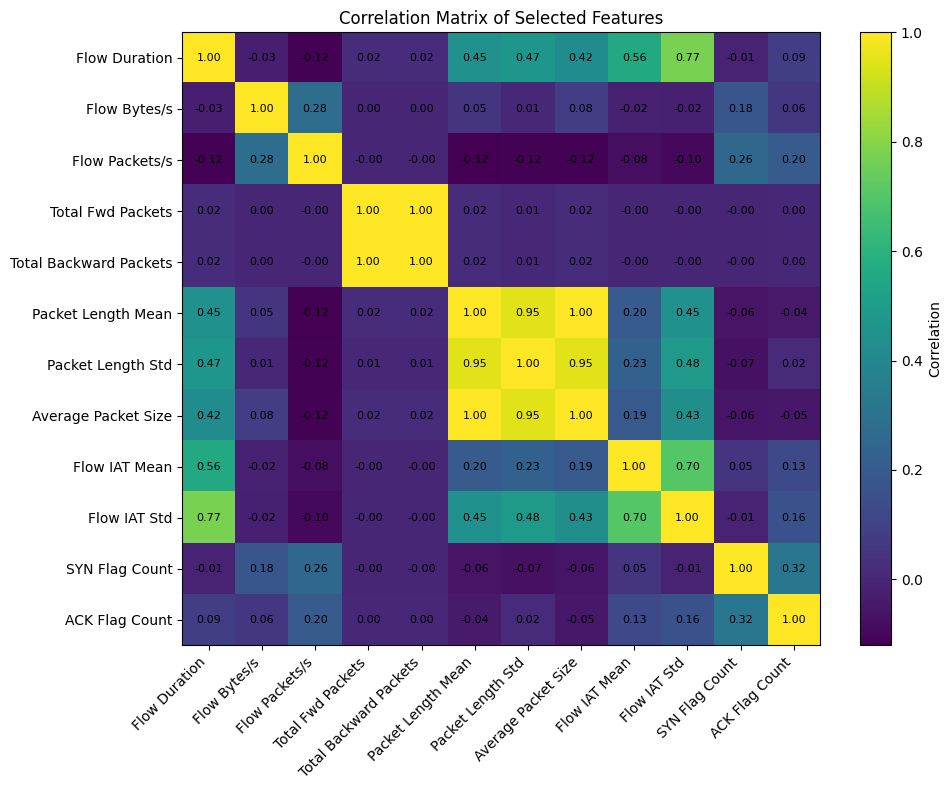

In [11]:
features = [
    'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
    'Total Fwd Packets', 'Total Backward Packets',
    'Packet Length Mean', 'Packet Length Std',
    'Average Packet Size', 'Flow IAT Mean', 'Flow IAT Std',
    'SYN Flag Count', 'ACK Flag Count'
]

corr = df_eda[features].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(
            j, i,
            f"{corr.iloc[i,j]:.2f}",
            ha='center',
            va='center',
            fontsize=8
        )

plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.savefig('../outputs/figures/Correlation_Matrix.png')
plt.show()

### Câu hỏi: Những đặc trưng nào đang mang thông tin tương tự nhau? Có đặc trưng nào tương quan mạnh và có thể gây dư thừa thông tin không?

Biểu đồ Correlation Matrix thể hiện mức độ tương quan tuyến tính giữa các đặc trưng được lựa chọn trong tập dữ liệu.

- Nhóm đặc trưng liên quan đến kích thước gói tin gồm **Packet Length Mean**, **Packet Length Std** và **Average Packet Size** có hệ số tương quan rất cao (0.95 - 1.00). Điều này cho thấy các đặc trưng này phản ánh những khía cạnh tương tự của kích thước gói tin và chứa nhiều thông tin liên quan đến nhau.

- Đặc trưng **Flow Duration** có tương quan khá mạnh với **Flow IAT Std** (0.77) và **Flow IAT Mean** (0.56). Kết quả này cho thấy thời gian tồn tại của một luồng mạng có mối liên hệ đáng kể với khoảng thời gian giữa các gói tin trong luồng đó.

- Hai đặc trưng **Flow IAT Mean** và **Flow IAT Std** cũng có tương quan dương tương đối cao (0.70), phản ánh rằng các luồng có khoảng cách trung bình giữa các gói tin lớn thường đồng thời có mức biến động thời gian cao hơn.

- Nhóm đặc trưng về số lượng gói tin gồm **Total Fwd Packets** và **Total Backward Packets** có hệ số tương quan gần bằng 1.00, cho thấy số lượng gói tin gửi và nhận trong các luồng mạng có xu hướng tăng giảm cùng nhau.

- Các đặc trưng **SYN Flag Count** và **ACK Flag Count** có hệ số tương quan thấp với phần lớn các đặc trưng còn lại. Điều này cho thấy chúng cung cấp những thông tin riêng biệt về trạng thái kết nối TCP và không phụ thuộc nhiều vào các đặc trưng lưu lượng hoặc thời gian.

Kết quả phân tích cho thấy một số nhóm đặc trưng có mức độ tương quan rất cao, đặc biệt là nhóm đặc trưng liên quan đến kích thước gói tin và số lượng gói tin. Trong khi đó, các đặc trưng TCP Flag lại mang tính độc lập hơn so với phần còn lại của dữ liệu. Điều này cho thấy tập đặc trưng được lựa chọn vừa chứa các đặc trưng bổ sung thông tin cho nhau, vừa tồn tại một số đặc trưng có khả năng phản ánh cùng một hành vi mạng.

## Boxplot theo Label - Các loại lưu lượng mạng khác nhau có thực sự khác nhau về mặt đặc trưng hay không?

### Boxplot theo Label cho Flow Duration

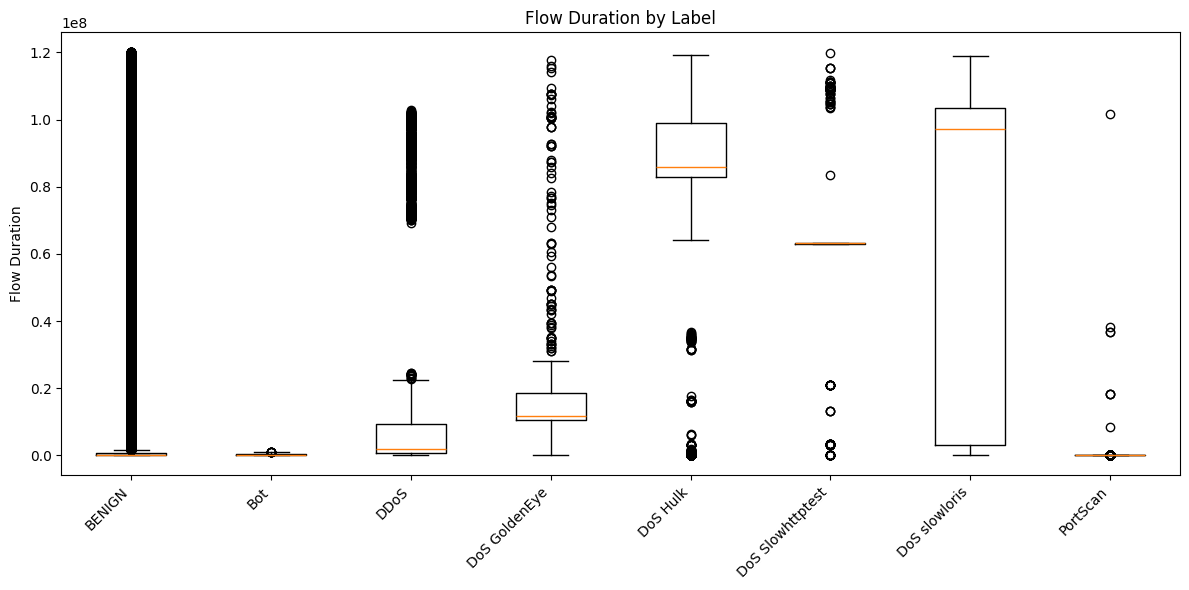

In [12]:
plt.figure(figsize=(12,6))

labels = sorted(df_eda['Label'].unique())

data = [
    df_eda[df_eda['Label'] == label]['Flow Duration']
    for label in labels
]

plt.boxplot(
    data,
    tick_labels=labels,
    showfliers=True
)

plt.xticks(rotation=45, ha='right')

plt.title('Flow Duration by Label')
plt.ylabel('Flow Duration')

plt.tight_layout()

plt.savefig('../outputs/figures/Boxplots_Outlier_theo_Label_cho_Flow_Duration.png')
plt.show()

Sự khác biệt giữa các nhãn được thể hiện khá rõ thông qua đặc trưng **Flow Duration**. Trong khi **BENIGN**, **Bot** và **PortScan** chủ yếu tập trung ở các giá trị thấp, nhiều loại tấn công như **DoS Hulk**, **DoS Slowloris**, **DoS Slowhttptest** và **Infiltration** lại có thời gian tồn tại của luồng mạng dài hơn đáng kể.

Đáng chú ý, **DoS Slowloris** và **Infiltration** có vùng phân bố rộng, cho thấy các kết nối thuộc hai nhóm này thường được duy trì trong thời gian dài. Điều này phù hợp với đặc điểm của các cuộc tấn công khai thác hoặc làm chậm quá trình xử lý kết nối của hệ thống.

Ngược lại, **PortScan** có giá trị tập trung gần vùng thấp nhất của biểu đồ. Kết quả này phản ánh đúng bản chất của hoạt động quét cổng khi kẻ tấn công liên tục tạo nhiều kết nối ngắn để kiểm tra trạng thái các cổng dịch vụ.

Nhìn chung, mỗi loại lưu lượng mạng thể hiện một mô hình thời gian kết nối khác nhau. Điều này cho thấy **Flow Duration** mang nhiều thông tin về hành vi của luồng mạng và có giá trị trong việc phân biệt giữa lưu lượng bình thường và các loại tấn công.

### Boxplot theo lable cho Flow Bytes/s

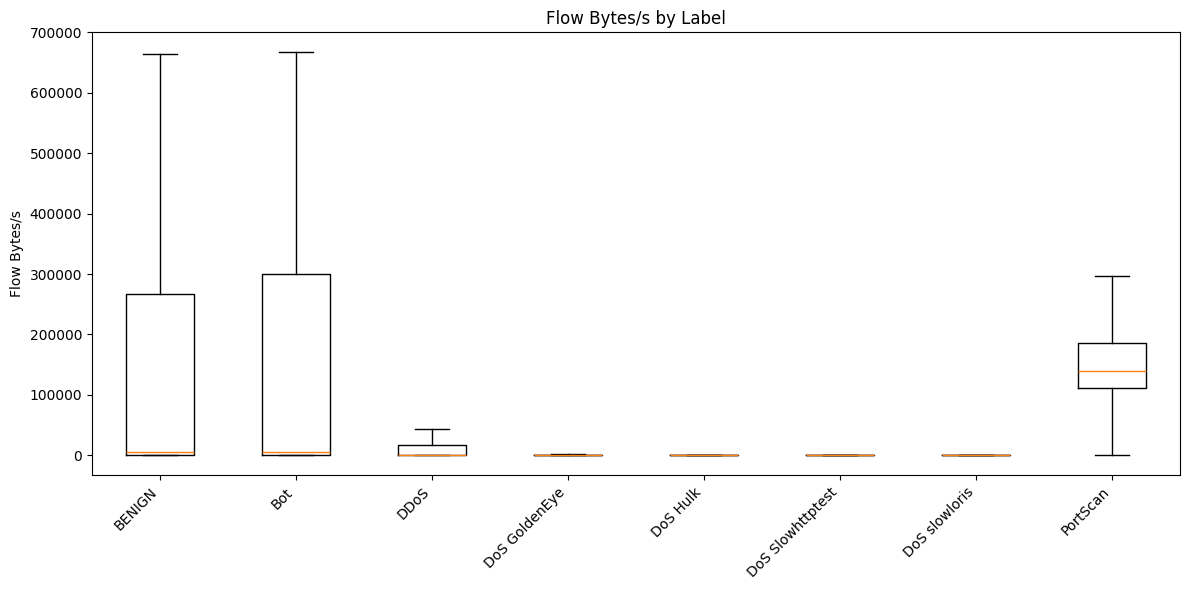

In [13]:
plt.figure(figsize=(12,6))

labels = sorted(df_eda['Label'].unique())

data = [
    df_eda[df_eda['Label'] == label]['Flow Bytes/s']
    for label in labels
]

plt.boxplot(
    data,
    tick_labels=labels,
    showfliers=False
)

plt.xticks(rotation=45, ha='right')

plt.title('Flow Bytes/s by Label')
plt.ylabel('Flow Bytes/s')

plt.tight_layout()

plt.savefig('../outputs/figures/Boxplots_Outlier_theo_Label_cho_Flow_Bytes_per_sec.png')
plt.show()

Biểu đồ cho thấy đặc trưng **Flow Bytes/s** có sự khác biệt rõ rệt giữa các loại lưu lượng mạng.

Điểm nổi bật nhất là **PortScan**, khi toàn bộ vùng phân bố nằm cao hơn đáng kể so với các nhãn còn lại. Giá trị trung vị của PortScan đạt mức rất cao, cho thấy các luồng thuộc loại này thường có tốc độ truyền dữ liệu lớn hơn nhiều so với phần lớn lưu lượng trong tập dữ liệu.

Ngược lại, các nhóm **DoS Hulk**, **DoS GoldenEye**, **DoS Slowloris** và **DoS Slowhttptest** đều tập trung ở vùng giá trị thấp. Điều này cho thấy các cuộc tấn công này không tạo ra lưu lượng dữ liệu lớn trên từng luồng riêng lẻ mà chủ yếu khai thác cơ chế kết nối hoặc tài nguyên của hệ thống.

Đối với **BENIGN** và **Bot**, mặc dù giá trị trung vị không cao, khoảng phân bố lại rất rộng. Điều này phản ánh sự đa dạng trong hoạt động của các luồng thuộc hai nhóm này, từ các kết nối có lưu lượng nhỏ đến các kết nối truyền tải lượng dữ liệu lớn.

Trong khi đó, **DDoS** và **Infiltration** nằm giữa hai nhóm trên, cho thấy mức độ trao đổi dữ liệu trung bình và không có sự tách biệt mạnh như PortScan.

Nhìn chung, sự khác biệt giữa các nhãn trên biểu đồ cho thấy **Flow Bytes/s** là một đặc trưng hữu ích để mô tả cường độ lưu lượng mạng và hỗ trợ phân biệt một số loại tấn công với lưu lượng bình thường.

### Boxplot theo label cho Average Packet Size

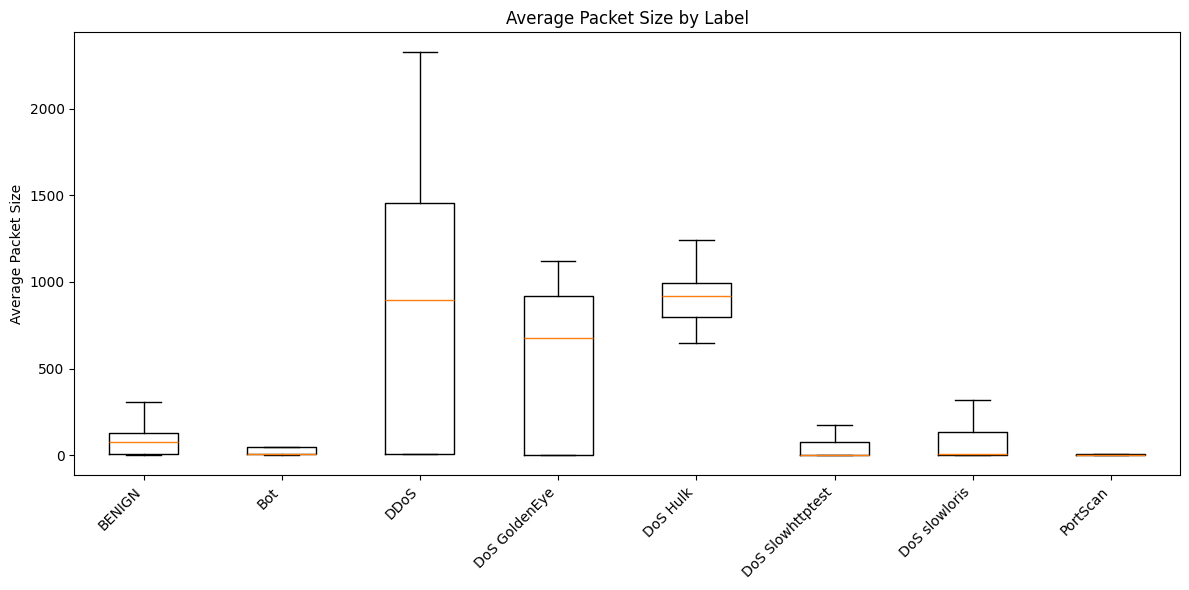

In [14]:
plt.figure(figsize=(12,6))

labels = sorted(df_eda['Label'].unique())

data = [
    df_eda[df_eda['Label'] == label]['Average Packet Size']
    for label in labels
]

plt.boxplot(
    data,
    tick_labels=labels,
    showfliers=False
)

plt.xticks(rotation=45, ha='right')

plt.title('Average Packet Size by Label')
plt.ylabel('Average Packet Size')

plt.tight_layout()
plt.savefig('../outputs/figures/Boxplots_Outlier_theo_Label_cho_Average_Packet_Size.png')
plt.show()

Dựa trên kích thước gói tin trung bình, các loại lưu lượng trong tập dữ liệu có thể được chia thành nhiều nhóm khác nhau.

Nhóm có kích thước gói tin lớn bao gồm **DoS Hulk**, **DDoS** và **DoS GoldenEye**. Các nhãn này đều có giá trị trung vị cao hơn đáng kể so với phần còn lại của tập dữ liệu, cho thấy các luồng mạng thuộc nhóm này thường truyền tải lượng dữ liệu lớn hơn trong mỗi gói tin.

Ở mức trung gian là **Infiltration**, với kích thước gói tin trung bình cao hơn lưu lượng bình thường nhưng thấp hơn đáng kể so với nhóm DoS và DDoS. Điều này cho thấy hành vi truyền dữ liệu của nhóm này mang đặc điểm riêng và không hoàn toàn giống các loại tấn công từ chối dịch vụ.

Trong khi đó, **BENIGN**, **Bot**, **DoS Slowloris** và **DoS Slowhttptest** tập trung chủ yếu ở vùng giá trị thấp. Đặc biệt, **PortScan** gần như nằm hoàn toàn ở mức thấp nhất trong tất cả các nhãn, phản ánh bản chất của hoạt động quét cổng khi chỉ cần trao đổi lượng dữ liệu rất nhỏ để kiểm tra trạng thái dịch vụ.

Sự phân tầng rõ rệt giữa các nhóm lưu lượng cho thấy kích thước gói tin trung bình không phân bố ngẫu nhiên mà gắn liền với đặc điểm hoạt động của từng loại lưu lượng mạng. Đây là một tín hiệu quan trọng có thể được khai thác trong quá trình phát hiện và phân loại tấn công.

### Bar Chart Average SYN Flag Count by Label

 Vì SYN Flag Count chỉ có giá trị 0 hoặc 1, nên Boxplot sẽ không đẹp và không mang lại nhiều thông tin.

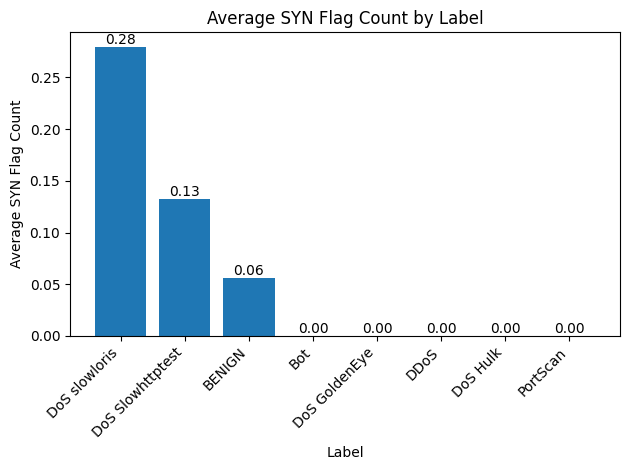

In [15]:
df_eda.groupby('Label')['SYN Flag Count'].mean()
syn_mean = (
    df_eda
    .groupby('Label')['SYN Flag Count']
    .mean()
    .sort_values(ascending=False)
)

bars = plt.bar(
    syn_mean.index,
    syn_mean.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')

plt.title('Average SYN Flag Count by Label')
plt.xlabel('Label')
plt.ylabel('Average SYN Flag Count')

plt.tight_layout()

plt.savefig('../outputs/figures/Bar_Chart_Average_SYN_Flag_Count_by_Label.png')
plt.show()

Khác với các đặc trưng về thời gian hay lưu lượng, **SYN Flag Count** phản ánh hành vi thiết lập kết nối TCP của từng loại lưu lượng mạng. Biểu đồ cho thấy mức độ sử dụng cờ SYN không đồng đều giữa các nhãn trong tập dữ liệu.

Có thể thấy **Infiltration** nổi bật hoàn toàn so với các nhãn còn lại khi giá trị trung bình đạt 1.00. Điều này cho thấy các luồng thuộc nhóm này gần như luôn xuất hiện gói tin SYN, phản ánh tần suất khởi tạo kết nối TCP rất cao.

Trong khi đó, **DoS Slowloris** và **DoS Slowhttptest** vẫn duy trì mức xuất hiện SYN Flag tương đối đáng kể. Đây là đặc điểm phù hợp với cơ chế hoạt động của các cuộc tấn công khai thác quá trình thiết lập và duy trì kết nối TCP nhằm làm cạn kiệt tài nguyên của hệ thống đích.

Ngược lại, phần lớn các nhãn như **DDoS**, **DoS Hulk**, **DoS GoldenEye**, **Bot** và **PortScan** gần như không sử dụng SYN Flag trong các luồng được ghi nhận. Điều này cho thấy hành vi của các loại lưu lượng này chủ yếu được phản ánh thông qua các đặc trưng khác thay vì quá trình khởi tạo kết nối.

Một điểm đáng chú ý là lưu lượng **BENIGN** vẫn xuất hiện SYN Flag nhưng với tỷ lệ thấp. Điều này phù hợp với hoạt động bình thường của mạng, khi chỉ một phần các luồng tương ứng với giai đoạn thiết lập kết nối TCP.

Biểu đồ cho thấy SYN Flag Count không phải là đặc trưng quan trọng đối với tất cả các loại lưu lượng mạng, nhưng lại mang giá trị nhận diện rõ rệt đối với một số nhãn cụ thể như **Infiltration**, **DoS Slowloris** và **DoS Slowhttptest**. Vì vậy, đặc trưng này có thể đóng vai trò bổ sung hữu ích khi xây dựng mô hình phát hiện xâm nhập mạng.